In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Dataset load karna
df = pd.read_csv('loan_approval_dataset.csv')

# 'loan_id' column drop karna
df.drop('loan_id', axis=1, inplace=True)

# Columns ke naam se extra space hatana aur lowercase karna
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

# Missing values check karna
print("Missing values:\n", df.isnull().sum())

Missing values:
 no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


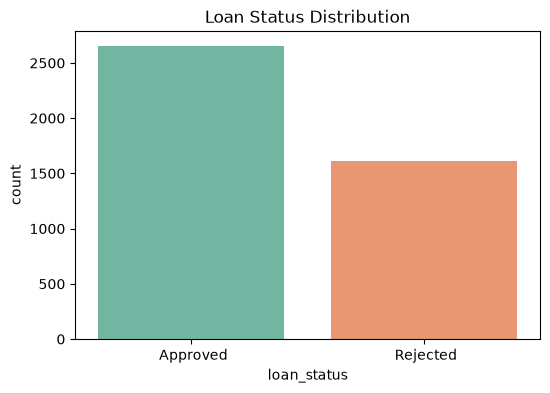

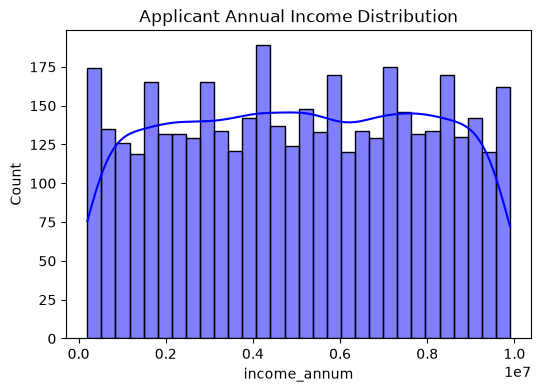

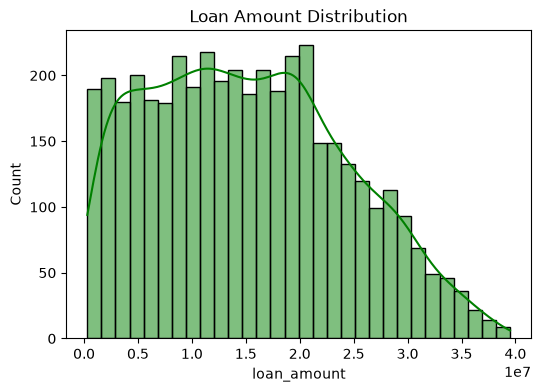

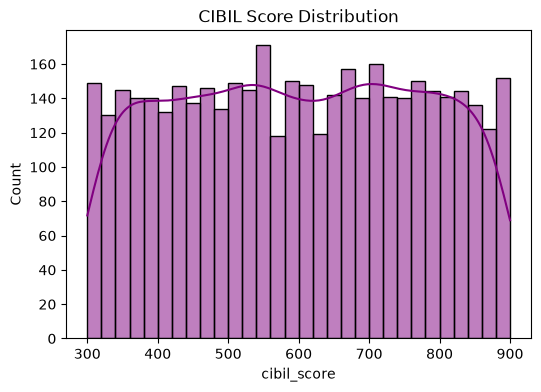

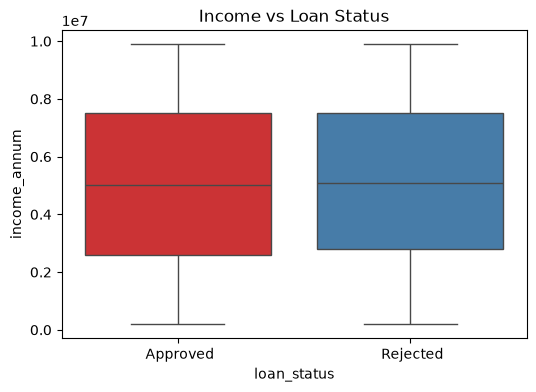

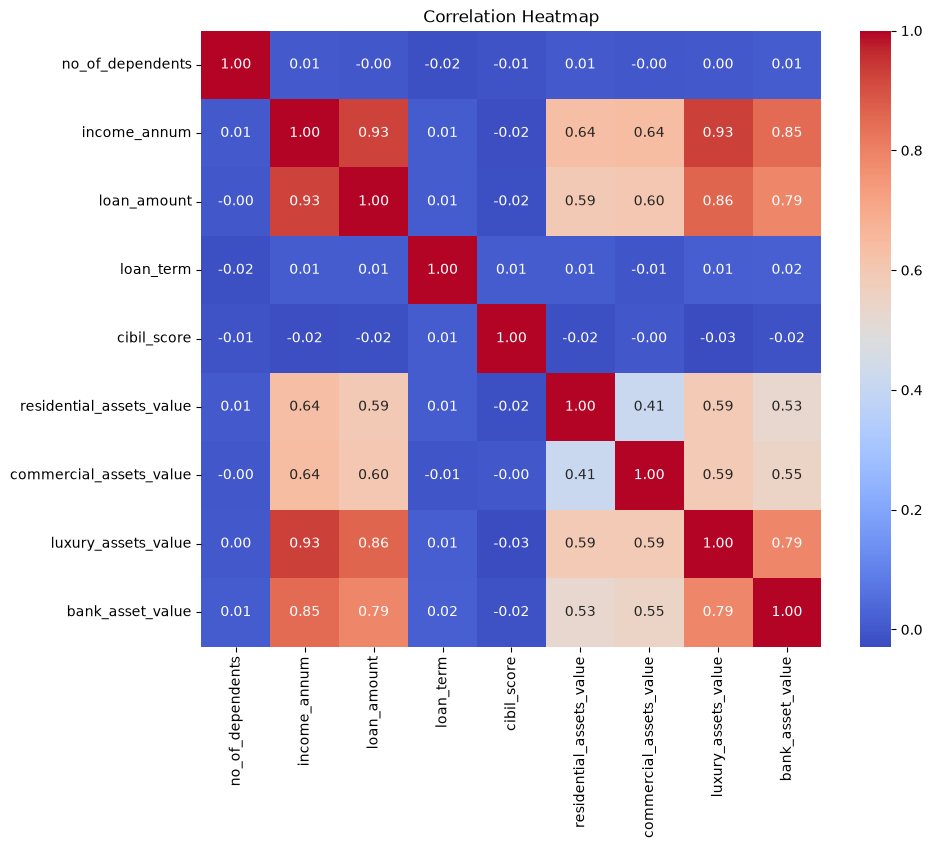

In [3]:
# 1. Distribution of loan status
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, hue='loan_status', legend=False, palette="Set2")
plt.title("Loan Status Distribution")
plt.show()

# 2. Income distribution
plt.figure(figsize=(6,4))
sns.histplot(df['income_annum'], bins=30, kde=True, color="blue")
plt.title("Applicant Annual Income Distribution")
plt.show()

# 3. Loan amount distribution
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amount'], bins=30, kde=True, color="green")
plt.title("Loan Amount Distribution")
plt.show()

# 4. CIBIL score distribution
plt.figure(figsize=(6,4))
sns.histplot(df['cibil_score'], bins=30, kde=True, color="purple")
plt.title("CIBIL Score Distribution")
plt.show()

# 5. Relationship between income and loan status
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='income_annum', data=df, hue='loan_status', legend=False, palette="Set1")
plt.title("Income vs Loan Status")
plt.show()

# 6. Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# Encode categorical variables
le = LabelEncoder()
for col in ['education', 'self_employed', 'loan_status']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
    else:
        print(f"Column '{col}' not found")

# Creating required columns
df['Debt to imcome ratio'] = df['loan_amount'] / df['income_annum']

df['total_assets'] = (df['residential_assets_value'] + 
                      df['commercial_assets_value'] + 
                      df['luxury_assets_value'] + 
                      df['bank_asset_value'])

print(df[['Debt to imcome ratio', 'total_assets']].head())

   Debt to imcome ratio  total_assets
0              3.114583      50700000
1              2.975610      17000000
2              3.263736      57700000
3              3.743902      52700000
4              2.469388      55000000


In [5]:
# Settings features & targets
feature_cols = [
    'no_of_dependents', 'education', 'self_employed', 'income_annum',
    'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 
    'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 
    'Debt to imcome ratio', 'total_assets'
]

X = df[feature_cols]
y = df['loan_status']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Logistic regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

# Prediction & probability
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:,1]

Accuracy:  0.927400468384075
Precision: 0.8760806916426513
Recall:    0.9411764705882353
F1 Score:  0.9074626865671642
ROC-AUC:   0.9659559333694822

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       531
           1       0.88      0.94      0.91       323

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854



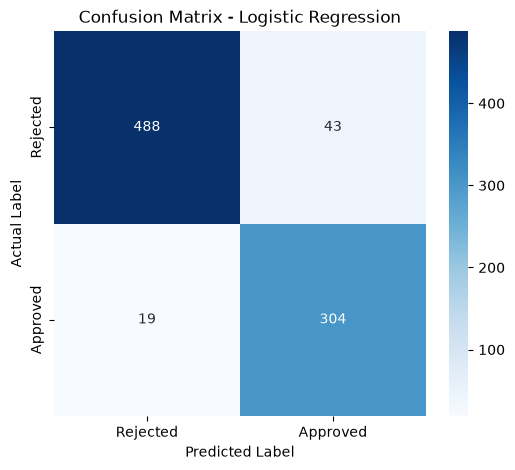

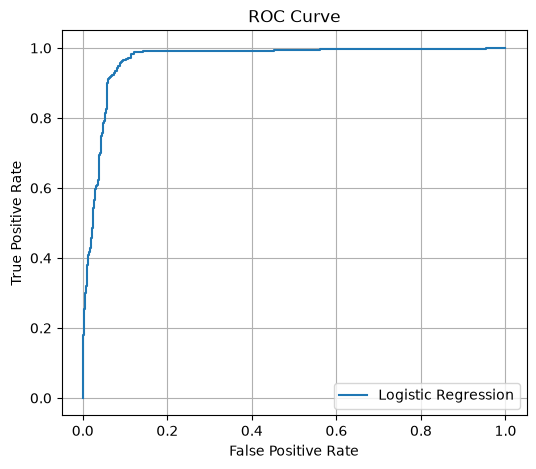

In [7]:
# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)   
plt.show()